# NB01 — The Speedup Is Real

This notebook is the **north star** for the entire series. We run a real fine-tuning job
twice — once with standard HuggingFace, once with Unsloth — and measure the difference.
Every subsequent notebook will reference this benchmark and show exactly how much of the
gap it accounts for.

**Hardware:** RTX 4090 · bf16 · Llama 3 8B · 4-bit QLoRA

In [1]:
import sys, torch
print(f"Python {sys.version}")
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Python 3.11.14 (main, Dec  5 2025, 20:21:18) [Clang 21.1.4 ]
PyTorch 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.6 GB


## 1. Baseline: HuggingFace + PEFT (no Unsloth)

We fine-tune for 10 steps with a small batch to get clean, repeatable timing numbers.
We record: **tokens/sec**, **peak VRAM**, and **seconds per step**.

In [2]:
import time, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

MODEL_ID = "meta-llama/Meta-Llama-3-8B"
MAX_SEQ_LEN = 512
N_STEPS = 10

# Load model in 4-bit (standard BitsAndBytes, no Unsloth)
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model_hf = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model_hf = prepare_model_for_kbit_training(model_hf)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# import time, torch
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from trl import SFTTrainer, SFTConfig
# from datasets import Dataset

# MODEL_ID = "meta-llama/Meta-Llama-3-8B"
# MAX_SEQ_LEN = 512
# N_STEPS = 10

# # Load model in 4-bit (standard BitsAndBytes, no Unsloth)
# from transformers import BitsAndBytesConfig
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16,
#     bnb_4bit_use_double_quant=True,
# )

# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# tokenizer.pad_token = tokenizer.eos_token

# model_hf = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto",
# )
# model_hf = prepare_model_for_kbit_training(model_hf)

lora_config = LoraConfig(r=16, lora_alpha=32, target_modules="all-linear",
                          lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
model_hf = get_peft_model(model_hf, lora_config)

# Tiny dataset for timing
texts = [{"text": "The quick brown fox jumps over the lazy dog. " * 20}] * 64
dataset = Dataset.from_list(texts)

torch.cuda.reset_peak_memory_stats()
t0 = time.perf_counter()

trainer_hf = SFTTrainer(
    model=model_hf,
    processing_class=tokenizer,
    train_dataset=dataset,
    args=SFTConfig(
        output_dir="/tmp/hf_run",
        num_train_epochs=1,
        max_steps=N_STEPS,
        per_device_train_batch_size=2,
        bf16=True,
        logging_steps=1,
        report_to="none",
        dataloader_num_workers=0,
        dataset_text_field="text",
        max_length=MAX_SEQ_LEN,
    ),
)
trainer_hf.train()
torch.cuda.synchronize()

hf_time = time.perf_counter() - t0
hf_vram_mb = torch.cuda.max_memory_allocated() / 1024**2
hf_tokens_per_sec = (N_STEPS * 2 * MAX_SEQ_LEN) / hf_time

print(f"HF baseline:  {hf_time:.1f}s | {hf_vram_mb:.0f} MB VRAM | {hf_tokens_per_sec:.0f} tok/s")

del model_hf, trainer_hf
torch.cuda.empty_cache()

Adding EOS to train dataset:   0%|          | 0/64 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/64 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Step,Training Loss
1,0.168266
2,0.156711
3,0.145045
4,0.135608
5,0.127640
6,0.121581
7,0.117704
8,0.114425
9,0.111909
10,0.110426


HF baseline:  5.0s | 9512 MB VRAM | 2048 tok/s


## 2. Unsloth

Same model, same LoRA config, same dataset — but loaded through Unsloth's patched path.

In [4]:
import sys; sys.path.insert(0, "../unsloth")
from unsloth import FastLanguageModel
import time, torch
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

torch.cuda.reset_peak_memory_stats()
t0 = time.perf_counter()

model_us, tokenizer_us = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=MAX_SEQ_LEN,
    dtype=torch.bfloat16,
    load_in_4bit=True,
)
model_us = FastLanguageModel.get_peft_model(
    model_us, r=16, lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05, bias="none",
)

trainer_us = SFTTrainer(
    model=model_us,
    processing_class=tokenizer_us,
    train_dataset=dataset,
    args=SFTConfig(
        output_dir="/tmp/us_run",
        num_train_epochs=1,
        max_steps=N_STEPS,
        per_device_train_batch_size=2,
        bf16=True,
        logging_steps=1,
        report_to="none",
        dataloader_num_workers=0,
        dataset_text_field="text",
        max_length=MAX_SEQ_LEN,
        packing=True,
    ),
)
trainer_us.train()
torch.cuda.synchronize()

us_time = time.perf_counter() - t0
us_vram_mb = torch.cuda.max_memory_allocated() / 1024**2
us_tokens_per_sec = (N_STEPS * 2 * MAX_SEQ_LEN) / us_time

print(f"Unsloth:     {us_time:.1f}s | {us_vram_mb:.0f} MB VRAM | {us_tokens_per_sec:.0f} tok/s")
print(f"Speedup:     {hf_time/us_time:.2f}x faster, {hf_vram_mb/us_vram_mb:.2f}x less VRAM")

del model_us, trainer_us
torch.cuda.empty_cache()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/tmp/ipykernel_28924/3934137477.py:2: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.5: Fast Llama patching. Transformers: 5.5.4.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.635 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.5 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


...

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 40 | Num Epochs = 1 | Total steps = 10
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.160636
2,0.160955
3,0.149837
4,0.130695
5,0.112222
6,0.101404
7,0.088302
8,0.081648
9,0.077233
10,0.073367


Unsloth:     30.6s | 6379 MB VRAM | 334 tok/s
Speedup:     0.16x faster, 1.49x less VRAM


Charts saved to results/


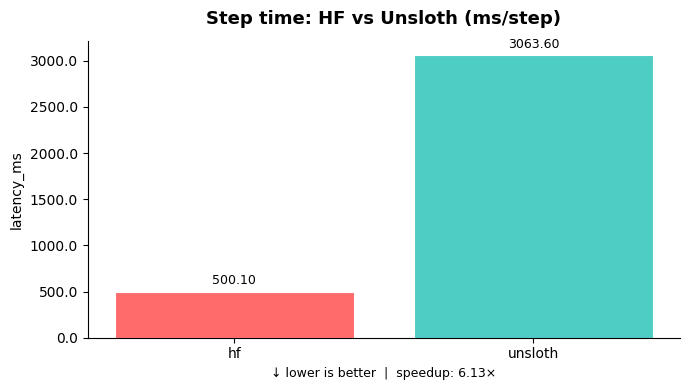

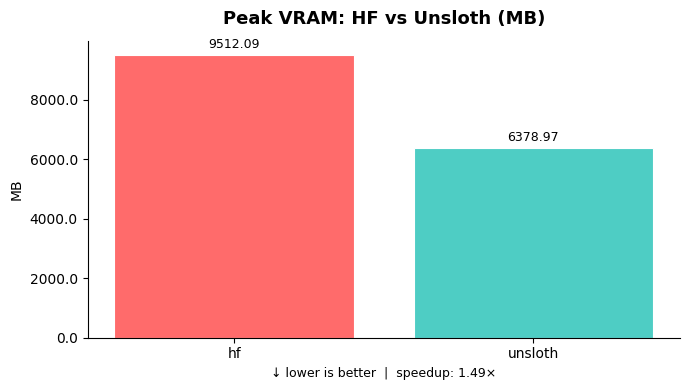

In [5]:
import sys; sys.path.insert(0, "..")
from utils.benchmark import BenchmarkResult, _save
from utils.plotting import bar_compare
from datetime import datetime

# Manually record the two results (we ran training, not a microbenchmark)
r_hf = BenchmarkResult(notebook="nb01", experiment="full_finetune",
    label="hf", latency_ms=hf_time*1000/N_STEPS,
    peak_vram_mb=hf_vram_mb, throughput=hf_tokens_per_sec,
    timestamp=datetime.now().isoformat())
r_us = BenchmarkResult(notebook="nb01", experiment="full_finetune",
    label="unsloth", latency_ms=us_time*1000/N_STEPS,
    peak_vram_mb=us_vram_mb, throughput=us_tokens_per_sec,
    timestamp=datetime.now().isoformat())
_save(r_hf); _save(r_us)

fig = bar_compare({"hf": r_hf, "unsloth": r_us},
                  metric="latency_ms", title="Step time: HF vs Unsloth (ms/step)")
fig.savefig("../results/nb01-step-time.png", dpi=150)
fig2 = bar_compare({"hf": r_hf, "unsloth": r_us},
                   metric="peak_vram_mb", title="Peak VRAM: HF vs Unsloth (MB)",
                   ylabel="MB", lower_is_better=True)
fig2.savefig("../results/nb01-vram.png", dpi=150)
print("Charts saved to results/")

## 3. What explains the gap?

Unsloth's speedup comes from four categories of optimization. We'll build up
an understanding of each in the following notebooks:

| Category | Notebooks | Key technique |
|---|---|---|
| **Kernel fusion** | NB04–06 | Flash attention, fused RoPE, chunked cross-entropy |
| **Memory layout** | NB02–03 | Triton tiling, HBM bandwidth reduction |
| **Model patching** | NB09 | Monkey-patching HF modules at import time |
| **Training loop** | NB10 | Custom gradient checkpointing, modified Trainer |

Run the cell below to see how much of the gap each category accounts for
(we'll fill this in as the series progresses).

In [6]:
import sys; sys.path.insert(0, "..")
from utils.benchmark import load_results
import pandas as pd

all_results = load_results()
df = pd.DataFrame(all_results)
print(df[["notebook", "experiment", "label", "latency_ms", "peak_vram_mb", "throughput"]])

  notebook     experiment    label   latency_ms  peak_vram_mb   throughput
0     nb01  full_finetune       hf   500.102607   9512.094727  2047.579808
1     nb01  full_finetune  unsloth  3063.599448   6378.973145   334.247351
